In [18]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li

from scipy.stats import chisquare


In [4]:
Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    'ESP Vibration X',
    'ESP Vibration Y',
    #'ESP Power',
    #"Well_down"
    ]

In [5]:
totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)
totalData.rename(columns={"index":"time"},inplace=True)
totalData.drop(columns=["Unnamed: 0"],inplace=True)

pumpList = totalData["Well Run"].unique()

totalData["Choke Closed"] = 1-totalData["Choke Opening"]
totalData["Radius"] = totalData[Headers].pow(2).sum(axis=1).pow(1/2)


/tmp/ipykernel_91986/3036563576.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  totalData = pd.read_csv("../data/totalProcessedData.csv",delimiter=",").fillna(0)


In [7]:
n = 3

mainSeed = 971215
np.random.seed(mainSeed)

seeds = np.random.randint(low=19971215,high=20210505,size=30)

medianList = np.array([]).astype(int)

for seed in seeds:
    X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=totalData)

    radiusData = totalData["Radius"].loc[totalData["Well_down"]==0]


    modelGMMradius = li.GaussianMixtureFit(radiusData,n,seed=mainSeed)
    
    modelRadius = hmm.GaussianHMM(
        n_components=n,
        random_state=mainSeed,
        covariance_type="full",
        init_params="st"
        )

    modelRadius.means_ = modelGMMradius.means_
    modelRadius.covars__ = modelGMMradius.covariances_

    modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)


    li.PostProcessing(modelRadius, totalData, modelData,"Radius", "State Radius", totalLength)

    totalData["State Radius"] = totalData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n))


    medianList_G = np.array([])

    for pump in pumpList:
        pumpData = totalData.loc[(totalData["Well Run"]==pump) & (totalData["Well_down"]==0) ]#.copy()
        last = pumpData.shape[0]
        pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
        medianList_G = np.append(medianList_G,pumpMedianR)


    medianList = np.concat((medianList, medianList_G))


AIC: 1823341.3206047846 BIC: 1823504.4186566893
AIC: 1834743.921239186 BIC: 1834907.0192910908
AIC: 1850244.8328516567 BIC: 1850407.9309035614
AIC: 1840696.0076676577 BIC: 1840859.1057195624
AIC: 1843716.8448703082 BIC: 1843879.9429222129
AIC: 1846682.5716054577 BIC: 1846845.6696573624
AIC: 1834875.2840149554 BIC: 1835038.38206686
AIC: 1862767.6653257613 BIC: 1862930.763377666
AIC: 1877129.5251827224 BIC: 1877292.623234627
AIC: 1833135.940673072 BIC: 1833299.0387249766
AIC: 1834053.0258456406 BIC: 1834216.1238975453
AIC: 1880902.7605028816 BIC: 1881065.8585547863
AIC: 1836811.9702726256 BIC: 1836975.0683245303
AIC: 1848750.8719226348 BIC: 1848913.9699745395
AIC: 1877391.973246467 BIC: 1877555.0712983718
AIC: 1857619.7506462177 BIC: 1857782.8486981224
AIC: 1839605.1114757112 BIC: 1839768.209527616
AIC: 1853236.0989095378 BIC: 1853399.1969614425
AIC: 1837475.0407349372 BIC: 1837638.1387868419
AIC: 1863121.9077354954 BIC: 1863285.0057874
AIC: 1850385.0122692194 BIC: 1850548.110321124
AIC:

In [8]:
saveA = np.array(medianList).T
pd.DataFrame(saveA,columns=["R"]).to_csv("saveA_direto.csv")

In [10]:
saveA = pd.read_csv("saveA_direto.csv")

In [11]:
medianListR = saveA["R"].to_numpy()

In [12]:
cmap = plt.get_cmap('Oranges', 4)

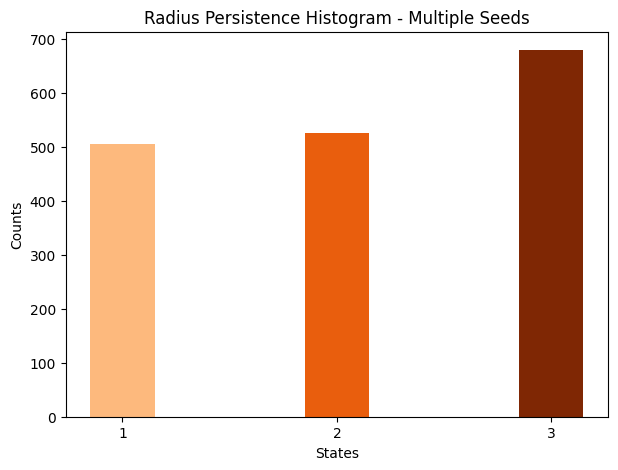

In [16]:

plt.figure(figsize=(7,5))

states,counts = np.unique(medianListR,return_counts=True)

plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
plt.xticks(states,np.int64(states))
plt.ylabel("Counts")
plt.xlabel("States")
plt.title("Radius Persistence Histogram - Multiple Seeds")
plt.savefig("../imagens_gerais/multiple_seeds_radius_histogram.jpg")


In [1]:
# plt.figure(figsize=(7,5))
# plt.hist(medianListV)
# plt.title("Histograma da média de Persistência de Estados - Módulo da Vibração")

In [ ]:
# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1],counts[2]]) # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")

Estatística qui-quadrado: 31.6526, p-valor: 0.0000
Rejeitamos H0: C ocorre significativamente mais do que o esperado.
